# F4 — Week 10 Performance Review

**Objective**: Review the optimisation performance of F4 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F4 (4D input, 1D output, maximisation)

This notebook loads the Week 10 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 4
N_DIMS = 4
N_INITIAL = 30
WEEK = 10
USE_LOG_SCALE = False
DATA_DIR = '../../data/f4/'

## Step 1 — Load Data

In [2]:
# Load Week 10 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F4 — Week 10 Data Summary
  Input dimensions:  4
  Total samples:     40
  Initial samples:   30
  Submissions:       10
  Input shape:       (40, 4)
  Output shape:      (40,)
  Best output:       0.532175
  Worst output:      -32.6257

Sample | x1 | x2 | x3 | x4 | y
-------------------------------------------------------------------------
   1(init) | 0.896981 | 0.725628 | 0.175404 | 0.701694 | -22.1083
   2(init) | 0.889356 | 0.499588 | 0.539269 | 0.508783 | -14.6014
   3(init) | 0.250946 | 0.033693 | 0.145380 | 0.494932 | -11.6999
   4(init) | 0.346962 | 0.006250 | 0.760564 | 0.613024 | -16.0538
   5(init) | 0.124871 | 0.129770 | 0.384400 | 0.287076 | -10.0696
   6(init) | 0.801303 | 0.500231 | 0.706645 | 0.195103 | -15.4871
   7(init) | 0.247708 | 0.060445 | 0.042186 | 0.441324 | -12.6817
   8(init) | 0.746702 | 0.757092 | 0.369353 | 0.206566 | -16.0264
   9(init) | 0.400665 | 0.072574 | 0.886768 | 0.243842 | -17.0492
  10(init) | 0.626071 | 0.586751 | 0.438806 | 0.778858 | -12.74

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

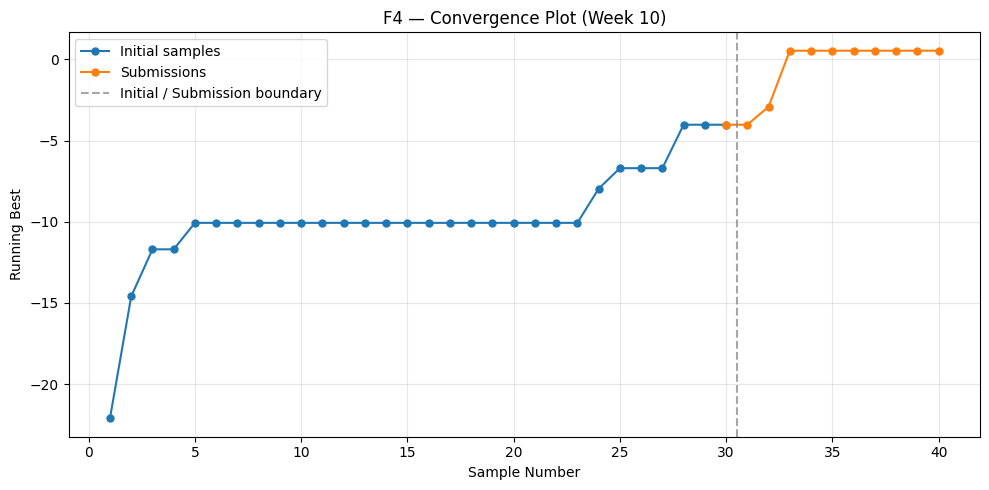

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

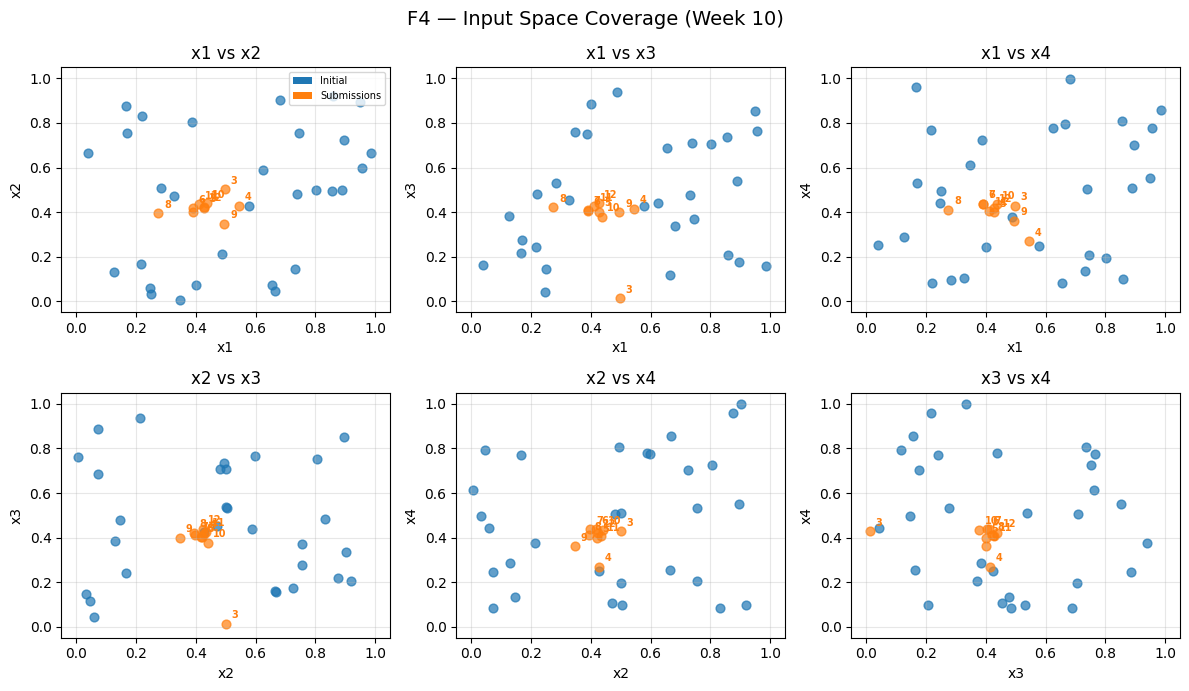

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: MFGP Matérn-2.5 + LinearTruncatedFidelityKernel
- **Acquisition**: MF-qNEI q=4, 64 fantasies
- **Key hyperparameters**: noise_lb=1e-4, fidelity fixed at 1.0

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     -4.02554
Best value (final):       0.532175
Improvements:             2/10
Max consecutive no-improve: 7
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |       -9.72048 |       -4.02554 | ✗
   4 |       -2.91276 |       -2.91276 | ✓
   5 |       0.532175 |       0.532175 | ✓
   6 |       0.338389 |       0.532175 | ✗
   7 |        0.24475 |       0.532175 | ✗
   8 |       -1.18949 |       0.532175 | ✗
   9 |       -1.03707 |       0.532175 | ✗
  10 |       0.155771 |       0.532175 | ✗
  11 |       0.523825 |       0.532175 | ✗
  12 |        0.44639 |       0.532175 | ✗


### Evaluation

F4 has shown **early gains followed by stalling** with **2 improvements** in 10 submission rounds. However, the absolute improvement is large: best moved from -4.026 (initial) to 0.532, crossing from negative to positive territory.

Key observations:
- Only 2/10 submissions improved the best, but the first improvement was substantial (from -4.03 to positive)
- 7 consecutive non-improving submissions in the later rounds indicate severe stalling
- The MFGP architecture is designed for multi-fidelity data, but F4 only has single-fidelity observations — this is a fundamental mismatch
- The LinearTruncatedFidelityKernel adds unnecessary complexity and parameters for single-fidelity data
- The pair plots across 6 dimension pairs show whether the 4D input space is being explored effectively

**Stalling status**: YES — 7 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

F4 shows early gains that have stalled (2/10 improvements, 7 consecutive non-improving). Key recommendation:

1. **Switch from MFGP to standard SFGP** — The MFGP with LinearTruncatedFidelityKernel is designed for multi-fidelity data, but F4 only has single-fidelity observations. The fidelity kernel adds unnecessary parameters and complexity without benefit. A standard SFGP with Matérn-2.5 ARD will be simpler and likely model the data better.

2. **Replace MF-qNEI with qLogNEI** — The multi-fidelity acquisition function is inappropriate for single-fidelity data. Standard qLogNEI with q=4 is the correct choice.

3. **Add output standardisation** — Apply Standardize(m=1) to handle the wide output range (from -4.03 to 0.53). This improves GP conditioning significantly.

4. **Increase noise lower bound** — With 30 initial + 10 submission = 40 samples in 4D, the GP may be overfitting. A noise_lb=1e-3 provides regularisation.

5. **Increase MLL restarts to 30+** — The 4D space with 40 observations needs thorough hyperparameter optimisation to avoid degenerate lengthscales.

**Priority**: HIGH — The MFGP/single-fidelity mismatch is a fundamental architecture issue that should be resolved.